## Hello on my Streamed SPOTIFY 

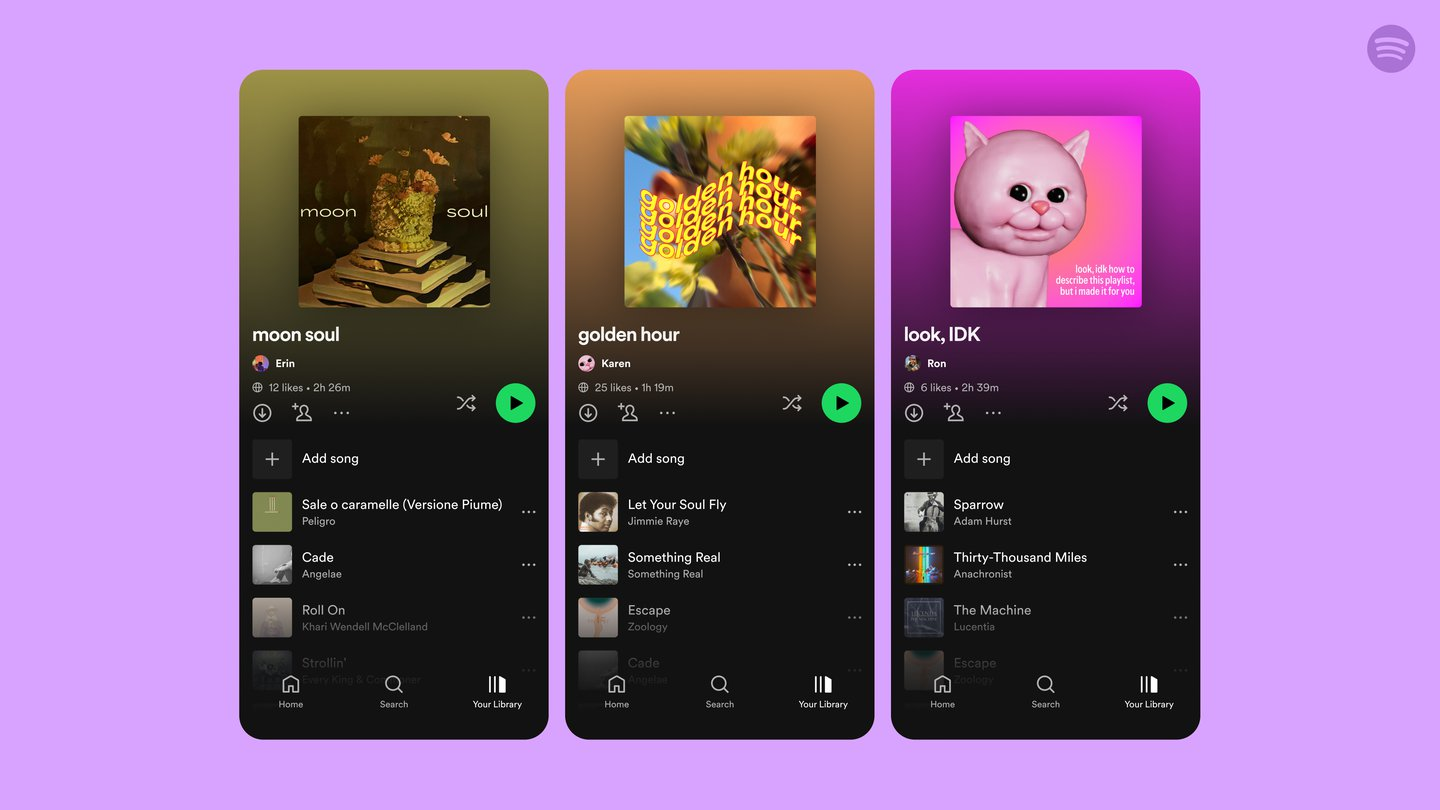

In [1]:
from IPython.display import Image, display

# Display the image
display(Image(filename='spotify.jpg'))

## Import Librairies

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## 🎧 STEP 1: Load Data 

In [7]:
# Load Data
Spotify = pd.read_csv('spotify2023.csv', encoding='latin-1')
# Display Dataset
Spotify
# # Display the first 5 rows of the Spotify dataset to get an initial overview of the data structure and content
Spotify.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## 🧹 STEP 2: Data Cleaning

In [8]:
# Display a concise summary of the dataset
Spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [9]:
# Check the number of missing values in each column
Spotify.isnull().sum()

track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

In [10]:
# Remove duplicates
Spotify.drop_duplicates(inplace=True)

In [12]:
# Handle missing values
Spotify.fillna(0, inplace=True)

## 🧠 STEP 3: Feature Engineering

In [15]:
Spotify.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [21]:
Spotify['streams'].head(10)

0    141381703
1    133716286
2    140003974
3    800840817
4    303236322
5    183706234
6    725980112
7     58149378
8     95217315
9    553634067
Name: streams, dtype: object

In [18]:
Spotify['streams'].describe()

count            817
unique           814
top       1223481149
freq               2
Name: streams, dtype: object

In [22]:
Spotify['streams'] = (
    Spotify['streams']
    .astype(str)
    .str.replace(',', '', regex=False)   # remove commas
    .str.strip()                         # remove spaces
)

In [23]:
Spotify['streams'] = pd.to_numeric(Spotify['streams'], errors='coerce')

In [24]:
print(Spotify['streams'].isnull().sum())

1


In [25]:
print(Spotify['streams'].max())

3562543890.0


In [26]:
# Create popularity level
Spotify['popularity_level'] = pd.qcut(
    Spotify['streams'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
Spotify

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_level
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,B,Major,80,89,83,31,0,8,4,Low
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,C#,Major,71,61,74,7,0,10,4,Low
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,F,Major,51,32,53,17,0,31,6,Low
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,A,Major,55,58,72,11,0,11,15,High
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,A,Minor,65,23,80,14,63,11,6,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363.0,61,...,A,Major,60,24,39,57,0,8,3,Low
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870.0,4,...,F#,Major,42,7,24,83,1,12,6,Low
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683.0,2,...,C#,Major,80,81,67,4,0,8,6,Low
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612.0,29,...,C#,Major,82,67,77,8,0,12,5,Low


In [29]:
# Extract release year
Spotify['released_year'] = Spotify['released_year'].astype(int)

## 📊 STEP 4: Exploratory Data Analysis (EDA)

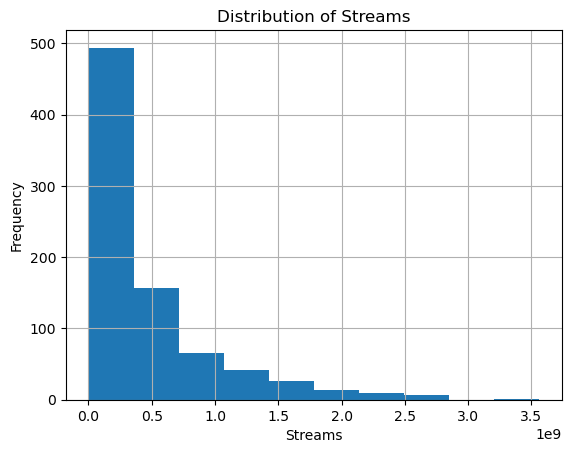

In [30]:
# Streams distribution
Spotify['streams'].hist()
plt.title("Distribution of Streams")
plt.xlabel("Streams")
plt.ylabel("Frequency")
plt.show()

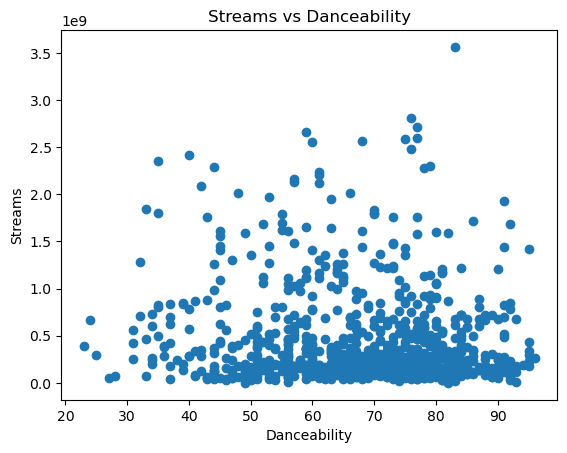

In [31]:
# Streams vs Danceability
plt.scatter(Spotify['danceability_%'], Spotify['streams'])
plt.xlabel("Danceability")
plt.ylabel("Streams")
plt.title("Streams vs Danceability")
plt.show()

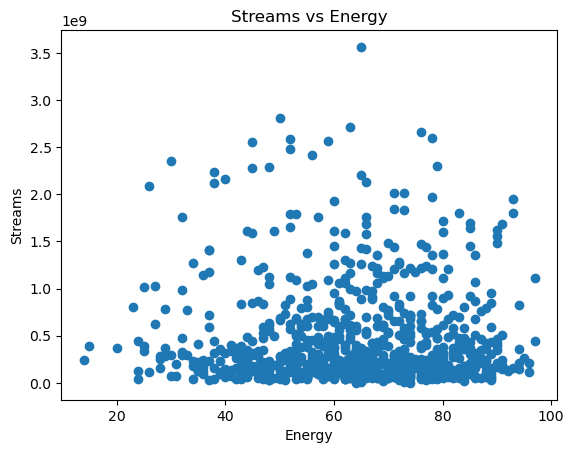

In [32]:
# Streams vs Energy
plt.scatter(Spotify['energy_%'], Spotify['streams'])
plt.xlabel("Energy")
plt.ylabel("Streams")
plt.title("Streams vs Energy")
plt.show()

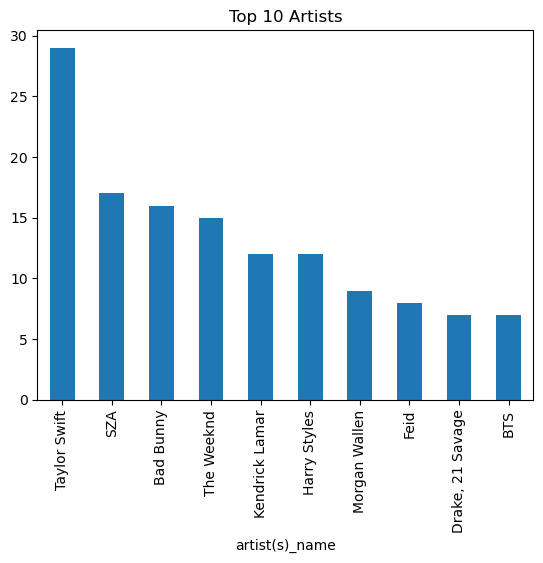

In [34]:
# Top 10 Artists
top_artists = Spotify['artist(s)_name'].value_counts().head(10)

top_artists.plot(kind='bar')
plt.title("Top 10 Artists")
plt.show()

In [35]:
# Most Popular songs
Spotify.sort_values(by='streams', ascending=False).head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_level
179,Shape of You,Ed Sheeran,1,2017,1,6,32181,10,3.562544e+09,33,...,C#,Minor,83,93,65,58,0,9,8,High
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2,2018,10,9,24094,78,2.808097e+09,372,...,D,Major,76,91,50,54,0,7,5,High
162,One Dance,"Drake, WizKid, Kyla",3,2016,4,4,43257,24,2.713922e+09,433,...,C#,Major,77,36,63,1,0,36,5,High
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2,2021,7,9,17050,36,2.665344e+09,492,...,C#,Major,59,48,76,4,0,10,5,High
140,Believer,Imagine Dragons,1,2017,1,31,18986,23,2.594040e+09,250,...,A#,Minor,77,74,78,4,0,23,11,High
725,Closer,"The Chainsmokers, Halsey",2,2016,5,31,28032,0,2.591224e+09,315,...,G#,Major,75,64,52,41,0,11,3,High
48,Starboy,"The Weeknd, Daft Punk",2,2016,9,21,29536,79,2.565530e+09,281,...,G,Major,68,49,59,16,0,13,28,High
138,Perfect,Ed Sheeran,1,2017,1,1,16596,13,2.559529e+09,7,...,G#,Major,60,17,45,16,0,11,2,High
693,Seï¿½ï¿½o,"Shawn Mendes, Camila Cabello",2,2019,6,19,15010,2,2.484813e+09,453,...,A,Minor,76,77,52,4,0,8,3,High
324,Say You Won't Let Go,James Arthur,1,2016,9,9,15722,16,2.420461e+09,231,...,A#,Major,40,45,56,69,0,9,5,High


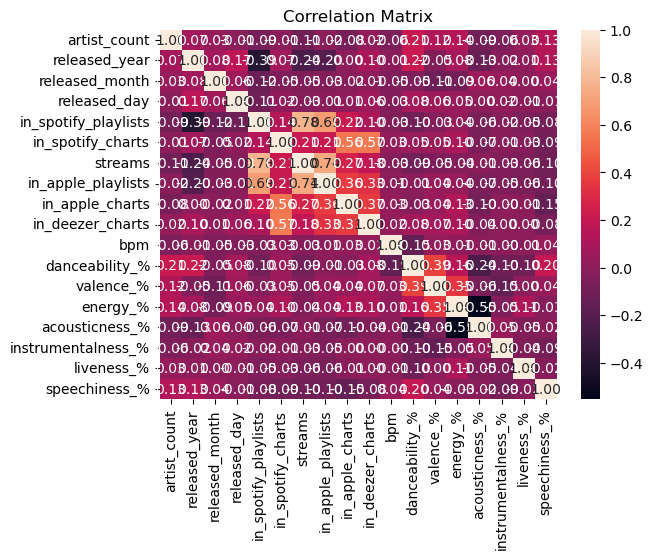

In [33]:
# Correlation Analysis
corr = Spotify.corr(numeric_only=True)

import seaborn as sns
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

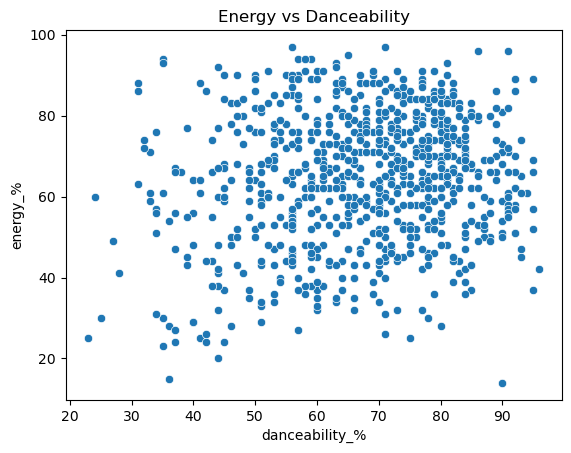

In [37]:
# Streams vs Danceability
sns.scatterplot(x='danceability_%', y='energy_%', data=Spotify)
plt.title("Energy vs Danceability")
plt.show()

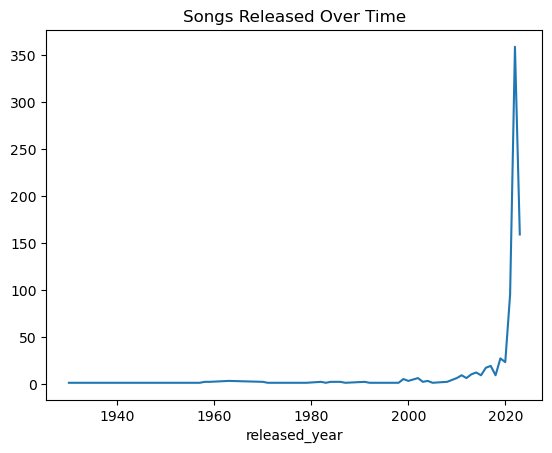

In [38]:
# Songs per Year
Spotify['released_year'].value_counts().sort_index().plot()
plt.title("Songs Released Over Time")
plt.show()

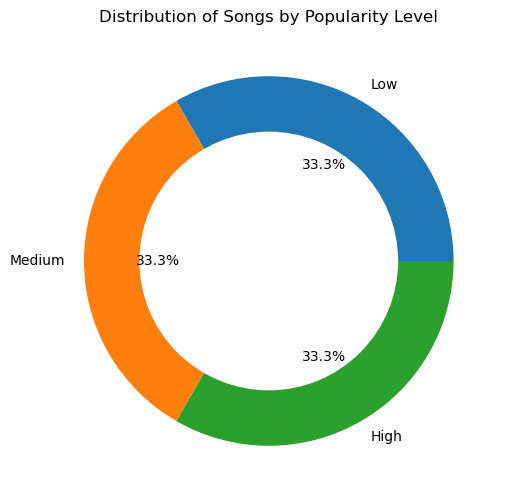

In [39]:
# Donut Chart (Popularity level)
pop_counts = Spotify['popularity_level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(pop_counts, labels=pop_counts.index, autopct='%1.1f%%')

# Make it donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Distribution of Songs by Popularity Level")
plt.show()

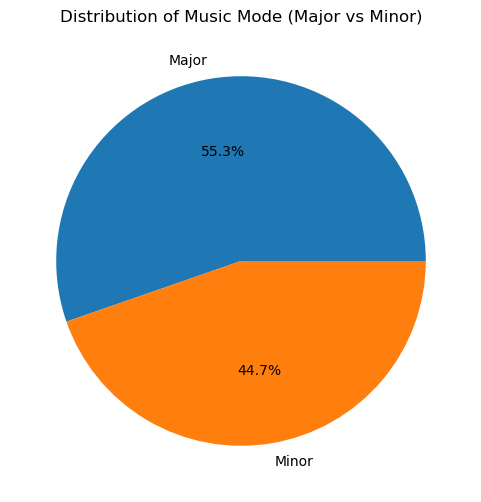

In [40]:
# Pie Chart (Music Mode)
mode_counts = Spotify['mode'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%')
plt.title("Distribution of Music Mode (Major vs Minor)")
plt.show()

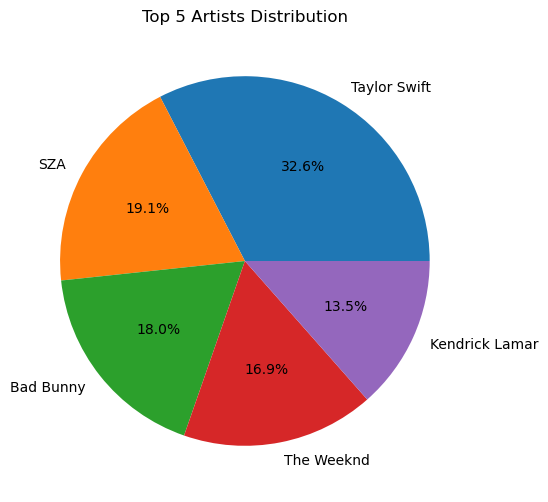

In [41]:
# Pie Chart (Top 5 Artists)
top_artists = Spotify['artist(s)_name'].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(top_artists, labels=top_artists.index, autopct='%1.1f%%')
plt.title("Top 5 Artists Distribution")
plt.show()

## WordCloud

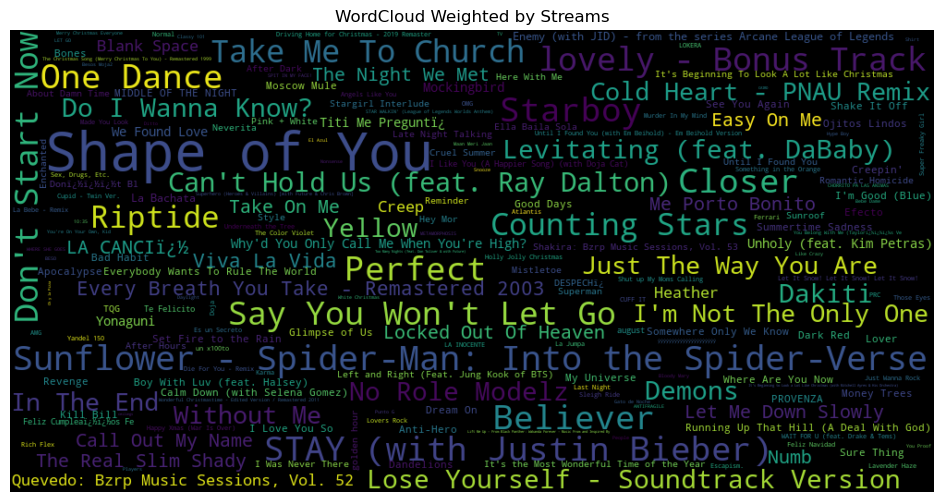

In [42]:
# Create dictionary (track_name: streams)
word_freq = dict(zip(Spotify['track_name'], Spotify['streams']))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Weighted by Streams")
plt.show()

## Code for MySQL

In [43]:
!pip install sqlalchemy pymysql pandas

In [45]:
from sqlalchemy import create_engine
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# MySQL connection
username = "root"
password = quote_plus("Admin@1234")   # encode @, !
host = "localhost"
port = "3306"
database = "Spotify"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "Spotistream"
Spotify.to_sql(
    table_name,
    con=engine,
    if_exists="replace",
    index=False
)

# Read back sample
pd.read_sql("SELECT * FROM SpotiStream LIMIT 5;", engine)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4768\1604543414.py:16: UserWarning: The provided table name 'Spotistream' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  Spotify.to_sql(


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_level
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,B,Major,80,89,83,31,0,8,4,Low
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,C#,Major,71,61,74,7,0,10,4,Low
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,F,Major,51,32,53,17,0,31,6,Low
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,A,Major,55,58,72,11,0,11,15,High
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,A,Minor,65,23,80,14,63,11,6,Medium
